# Sistem Klasifikasi Musik Genre Lagu

# Visualisasi EDA

📁 Saving results to: c:\Users\adief\OneDrive\Dokumen\Semester 5\Data Mining 2\Week 14 (Final Project)\results_comparison
📊 Memulai Analisis Visualisasi Data...


Matching files:   0%|          | 0/701 [00:00<?, ?it/s]


✅ Total Lagu Terpadu: 530
🎵 Genre yang tersedia: ['Pop' 'R&B' 'Hip Hop' 'EDM']


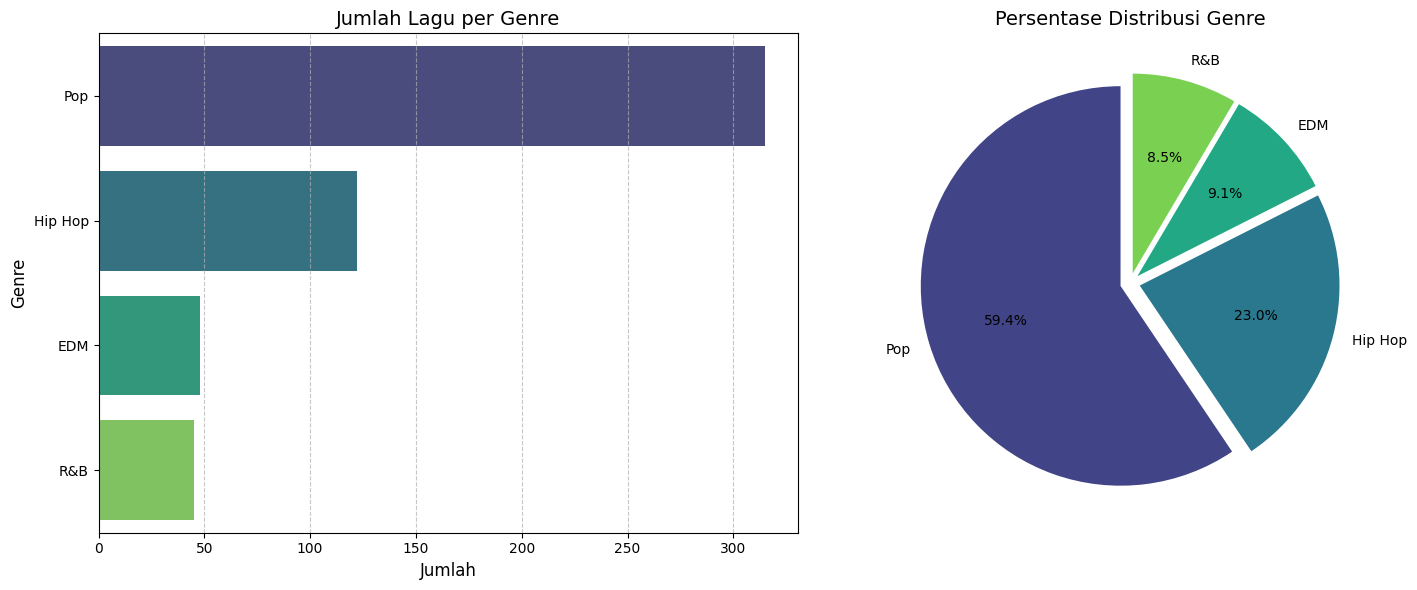

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from Modelling_Fix import load_metadata_robust, match_audio_files, BASE_PATH, AUDIO_DIR

# --- EDA (Exploratory Data Analysis) ---
print("📊 Memulai Analisis Visualisasi Data...")

# 1. Load Data
# Menggunakan fungsi loading yang sama agar konsisten dengan data training
df_eda = load_metadata_robust(BASE_PATH)
df_eda = match_audio_files(df_eda, AUDIO_DIR)

# 2. Tampilkan Statistik Singkat
print(f"\n✅ Total Lagu Terpadu: {len(df_eda)}")
print(f"🎵 Genre yang tersedia: {df_eda['genre_clean'].unique()}")

# 3. Visualisasi Distribusi
plt.figure(figsize=(15, 6))

# Plot 1: Bar Chart (Jumlah Lagu per Genre)
plt.subplot(1, 2, 1)
sns.countplot(y=df_eda['genre_clean'], 
              order=df_eda['genre_clean'].value_counts().index, 
              palette='viridis')
plt.title('Jumlah Lagu per Genre', fontsize=14)
plt.xlabel('Jumlah', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot 2: Pie Chart (Persentase)
plt.subplot(1, 2, 2)
df_eda['genre_clean'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors=sns.color_palette('viridis', len(df_eda['genre_clean'].unique())),
    startangle=90,
    explode=[0.05] * len(df_eda['genre_clean'].unique()) # Memberi sedikit jarak antar slice
)
plt.title('Persentase Distribusi Genre', fontsize=14)
plt.ylabel('') # Menghilangkan label y standard pie chart

plt.tight_layout()
plt.show()

# Visualisasi Preprocessing pada Lagu

📊 STARTING DATA & METADATA VERIFICATION PROCEDURE...

📂 Loading Metadata & Matching Audio Files...


Matching files:   0%|          | 0/701 [00:00<?, ?it/s]

✅ Total Valid Samples: 530

🔍 VERIFIKASI PEMBERSIHAN METADATA
--------------------------------------------------
Tabel Sampel: Perbandingan Label Asli vs Label Bersih
                            title genre genre_clean
Beautiful Now (feat. Jon Bellion)   edm         EDM
                             Cuek   pop         Pop
                            Sorry   pop         Pop
         Worth It (feat. Kid Ink)   rnb         R&B
                             Gone   pop         Pop


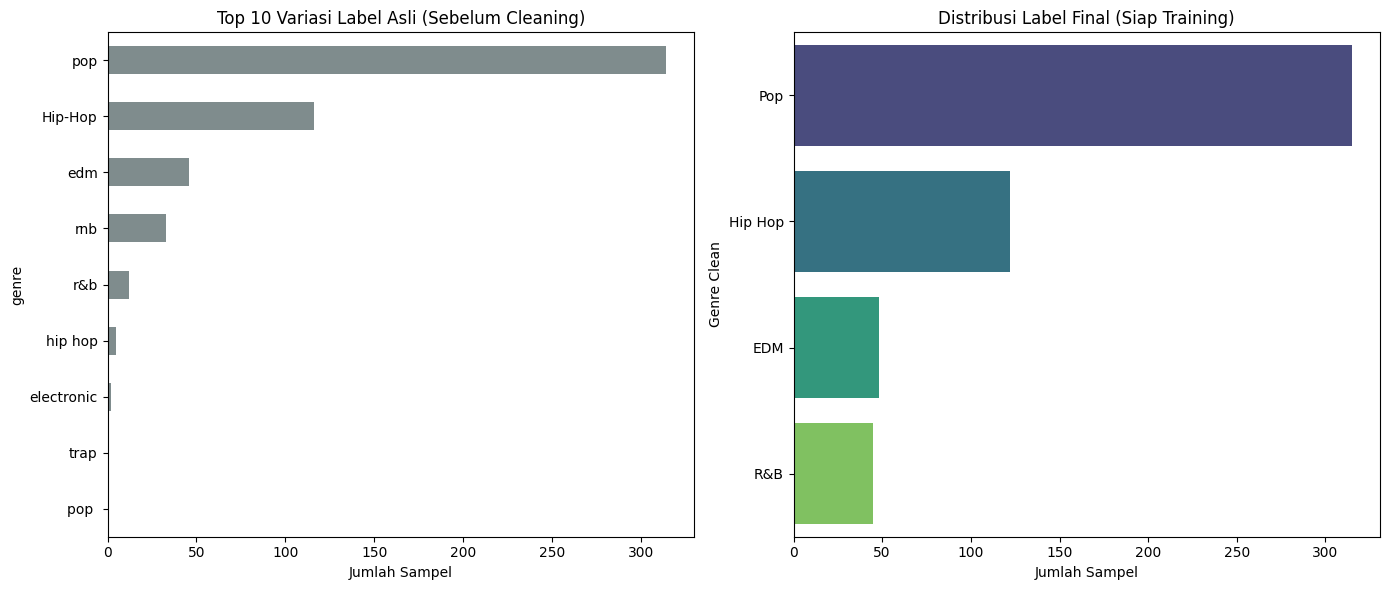


🎧 VERIFIKASI KONSISTENSI AUDIO (Preprocessing Check)
Target: 120 detik | 22050 Hz | Stereo (2 Channel)
--------------------------------------------------
🎵 File: qZjYggYSzc8 - Maroon 5 - Memories (Audio...
   └─ Raw: 48000Hz | 2 Ch | 190.7s
   └─ Final: 22050Hz | 2 Ch | 120.0s ✅ OK
🎵 File: FB1YNEOspyA - Keisya Levronka - Tak Ingi...
   └─ Raw: 48000Hz | 2 Ch | 272.8s
   └─ Final: 22050Hz | 2 Ch | 120.0s ✅ OK
🎵 File: NywWB67Z7zQ - Justin Bieber - What Do Yo...
   └─ Raw: 48000Hz | 2 Ch | 205.9s
   └─ Final: 22050Hz | 2 Ch | 120.0s ✅ OK


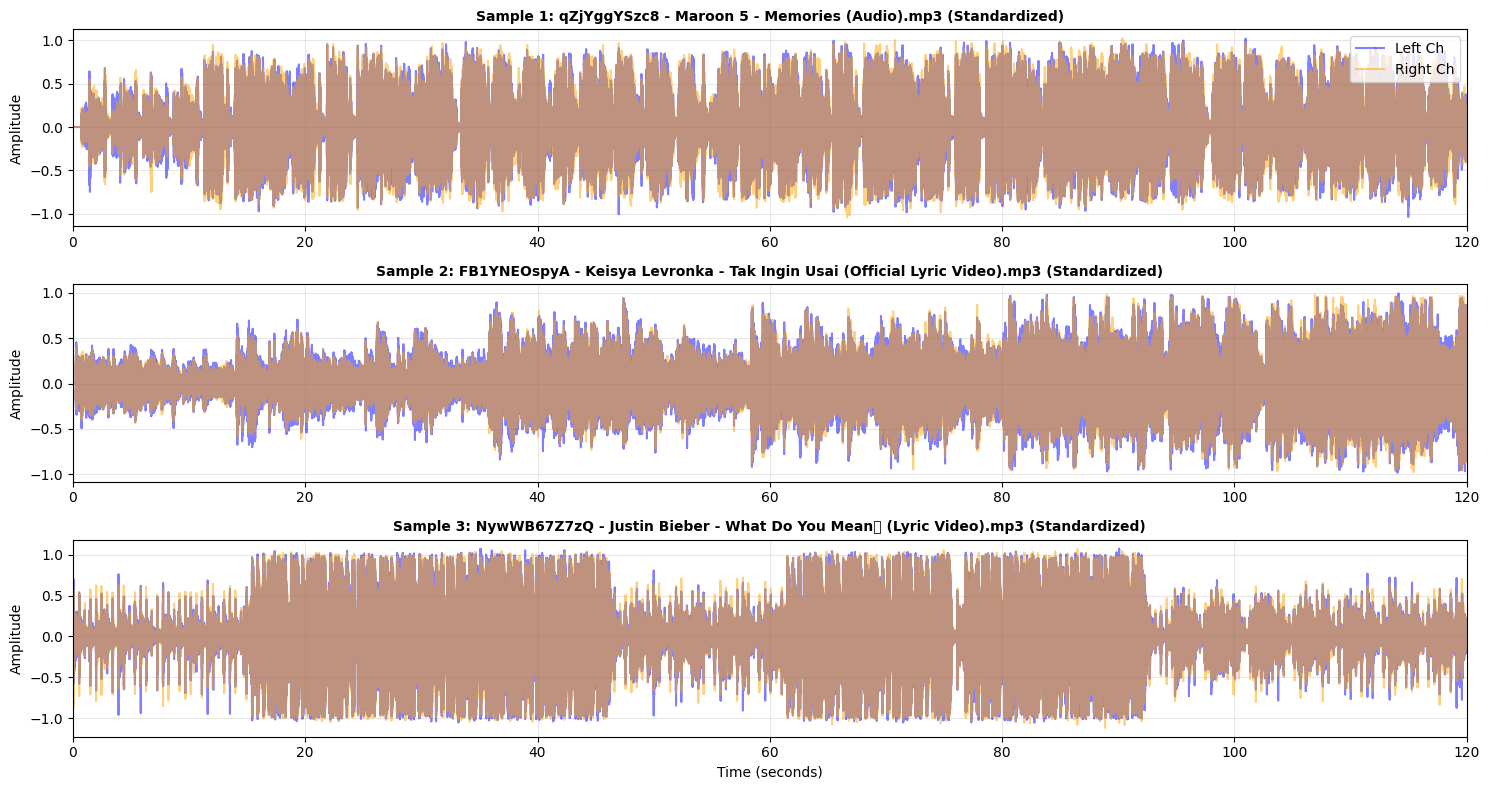


✅ Kesimpulan EDA: Seluruh data telah divalidasi konsistensinya dan siap untuk modelling.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F
import os
from Modelling_Fix import load_metadata_robust, match_audio_files, BASE_PATH, AUDIO_DIR

TARGET_SR = 22050
TARGET_DURATION = 120
TARGET_SAMPLES = TARGET_SR * TARGET_DURATION

print("📊 STARTING DATA & METADATA VERIFICATION PROCEDURE...\n")

# 1. LOAD DATASET
# ---------------------------------------------------------
print("📂 Loading Metadata & Matching Audio Files...")
df_eda = load_metadata_robust(BASE_PATH)
df_eda = match_audio_files(df_eda, AUDIO_DIR)
print(f"✅ Total Valid Samples: {len(df_eda)}")

# 2. VISUALISASI METADATA CLEANING (Mapping Verification)
# ---------------------------------------------------------
print("\n🔍 VERIFIKASI PEMBERSIHAN METADATA")
print("-" * 50)

# Tampilkan sampel data untuk membuktikan mapping/cleaning
print("Tabel Sampel: Perbandingan Label Asli vs Label Bersih")
print(df_eda[['title', 'genre', 'genre_clean']].sample(5).to_string(index=False))

plt.figure(figsize=(14, 6))

# Plot 1: Variasi Penulisan Genre Asli (Top 10)
# 'genre' adalah kolom raw, 'genre_clean' adalah hasil mapping
plt.subplot(1, 2, 1)
df_eda['genre'].value_counts().nlargest(10).sort_values().plot(kind='barh', color='#7f8c8d')
plt.title('Top 10 Variasi Label Asli (Sebelum Cleaning)', fontsize=12)
plt.xlabel('Jumlah Sampel')

# Plot 2: Distribusi Genre Final
plt.subplot(1, 2, 2)
sns.countplot(y=df_eda['genre_clean'], 
              order=df_eda['genre_clean'].value_counts().index, 
              palette='viridis')
plt.title('Distribusi Label Final (Siap Training)', fontsize=12)
plt.xlabel('Jumlah Sampel')
plt.ylabel('Genre Clean')

plt.tight_layout()
plt.show()

# 3. VISUALISASI KONSISTENSI AUDIO (Preprocessing Verification)
# ---------------------------------------------------------
print("\n🎧 VERIFIKASI KONSISTENSI AUDIO (Preprocessing Check)")
print(f"Target: {TARGET_DURATION} detik | {TARGET_SR} Hz | Stereo (2 Channel)")
print("-" * 50)

def simulate_pipeline_metrics(file_path):
    try:
        # Load Raw
        wav, sr = torchaudio.load(file_path)
        raw_desc = f"Raw: {sr}Hz | {wav.shape[0]} Ch | {wav.shape[1]/sr:.1f}s"
        
        # 1. Stereo Check
        if wav.shape[0] == 1: wav = wav.repeat(2, 1)
        elif wav.shape[0] > 2: wav = wav[:2, :]
        
        # 2. Resample
        if sr != TARGET_SR:
            resampler = T.Resample(sr, TARGET_SR)
            wav = resampler(wav)
            
        # 3. Duration Normalization (Pad/Crop)
        if wav.shape[1] > TARGET_SAMPLES:
            wav = wav[:, :TARGET_SAMPLES] # Center crop for viz usually, but simple crop here
        else:
            pad_amt = TARGET_SAMPLES - wav.shape[1]
            wav = F.pad(wav, (0, pad_amt))
            
        final_desc = f"Final: {TARGET_SR}Hz | {wav.shape[0]} Ch | {wav.shape[1]/TARGET_SR:.1f}s"
        return wav, raw_desc, final_desc
    except Exception as e:
        return None, str(e), "Error"

# Ambil 3 sampel acak untuk dibuktikan
sample_files = df_eda['file_path'].sample(3).values

plt.figure(figsize=(15, 8))

for i, fpath in enumerate(sample_files):
    fname = os.path.basename(fpath)
    wav_tensor, raw_info, final_info = simulate_pipeline_metrics(fpath)
    
    if wav_tensor is not None:
        # Print Log
        print(f"🎵 File: {fname[:40]}...")
        print(f"   └─ {raw_info}")
        print(f"   └─ {final_info} ✅ OK")
        
        # Visualisasi Waveform
        ax = plt.subplot(3, 1, i+1)
        # Plot Left Channel (Blue) & Right Channel (Orange) - alpha blended
        time_axis = torch.linspace(0, TARGET_DURATION, steps=wav_tensor.shape[1])
        ax.plot(time_axis.numpy(), wav_tensor[0].numpy(), color='blue', alpha=0.5, label='Left Ch')
        ax.plot(time_axis.numpy(), wav_tensor[1].numpy(), color='orange', alpha=0.5, label='Right Ch')
        
        ax.set_title(f"Sample {i+1}: {fname} (Standardized)", fontsize=10, fontweight='bold')
        ax.set_ylabel("Amplitude")
        ax.set_xlim(0, TARGET_DURATION)
        ax.grid(True, alpha=0.3)
        if i == 0: ax.legend(loc='upper right')

plt.xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

print("\n✅ Kesimpulan EDA: Seluruh data telah divalidasi konsistensinya dan siap untuk modelling.")

# Modelling Klasifikasi Genre Lagu

In [1]:
import os
import glob
import re
import unicodedata
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torchvision import models
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# CONFIG
SAMPLE_RATE = 22050
DURATION = 120
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 1024
BATCH_SIZE = 4
ACCUM_STEPS = 8
EPOCHS = 15
PATIENCE = 3
FIXED_GENRES = ['Pop', 'Hip Hop', 'R&B', 'EDM']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# PATHS
BASE_PATH = r'c:/Users/adief/OneDrive/Dokumen/Semester 5/Data Mining 2/Week 14 (Final Project)'
AUDIO_DIR = os.path.normpath(os.path.join(BASE_PATH, 'downloads_mp3'))
RESULTS_DIR = os.path.normpath(os.path.join(BASE_PATH, 'results_comparison'))
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"📁 Saving results to: {RESULTS_DIR}")

# 1. UTILS
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

def normalize_text(s):
    s = str(s).lower()
    s = unicodedata.normalize('NFKD', s).encode('ascii','ignore').decode('ascii')
    s = s.replace('.mp3', ' ')
    s = re.sub(r'\[(.*?)\]|\((.*?)\)', ' ', s)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def get_canonical_genre(g):
    GENRE_MAP = {
        'hip hop': 'Hip Hop', 'hiphop': 'Hip Hop', 'hip-hop': 'Hip Hop', 'rap': 'Hip Hop',
        'r&b': 'R&B', 'r b': 'R&B', 'rnb': 'R&B',
        'edm': 'EDM', 'electronic': 'EDM', 'house': 'EDM', 'techno': 'EDM', 'dance': 'EDM',
        'trance': 'EDM', 'dubstep': 'EDM',
        'pop': 'Pop', 'dance pop': 'Pop',
        'rock': 'Rock', 'alternative rock': 'Rock', 'classic rock': 'Rock',
        'country': 'Country',
        'folk': 'Folk', 'acoustic': 'Folk',
        'indie': 'Indie', 'indie rock': 'Indie', 'indie pop': 'Indie',
        'soul': 'Soul', 'r&b/soul': 'Soul'
    }
    g = normalize_text(g)
    for key, val in GENRE_MAP.items():
        if key in g: return val
    return None

def load_metadata_robust(base_path):
    files = glob.glob(os.path.join(base_path, '*.csv'))
    dfs = []
    for f in files:
        for enc in ['utf-8', 'latin1', 'cp1252']:
            try:
                df = pd.read_csv(f, encoding=enc)
                df = df[['title','artist','genre']].dropna()
                df['norm_title'] = df['title'].apply(normalize_text)
                df['norm_artist'] = df['artist'].apply(normalize_text)
                df['genre_clean'] = df['genre'].apply(get_canonical_genre)
                df = df[df['genre_clean'].isin(FIXED_GENRES)]
                dfs.append(df)
                break
            except: continue
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def match_audio_files(meta_df, audio_dir):
    audio_files = []
    for root, _, files in os.walk(audio_dir):
        for file in files:
            if file.endswith('.mp3'):
                path = os.path.join(root, file).replace('\\', '/')
                audio_files.append({'path': path, 'norm_name': normalize_text(file)})
    
    matches = []
    for idx, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc="Matching files"):
        title = row['norm_title']
        artist = row['norm_artist']
        found = None
        for audio in audio_files:
            if title in audio['norm_name'] and artist in audio['norm_name']:
                found = audio['path']
                break
        matches.append(found)
    meta_df['file_path'] = matches
    return meta_df.dropna(subset=['file_path'])

# 2. DATASET
class StereoSpecDataset(Dataset):
    def __init__(self, df, le, train=True):
        self.df = df
        self.le = le
        self.train = train
        self.mel_transform = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        self.max_len = SAMPLE_RATE * DURATION

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            wav, sr = torchaudio.load(row['file_path'])
            # Stereo Check
            if wav.shape[0] == 1: wav = wav.repeat(2, 1)
            elif wav.shape[0] > 2: wav = wav[:2, :]
            
            if sr != SAMPLE_RATE:
                wav = T.Resample(sr, SAMPLE_RATE)(wav)
            
            # Crop/Pad
            if wav.shape[1] > self.max_len:
                start = random.randint(0, wav.shape[1] - self.max_len) if self.train else (wav.shape[1] - self.max_len)//2
                wav = wav[:, start:start+self.max_len]
            else:
                wav = F.pad(wav, (0, self.max_len - wav.shape[1]))
            
            # Spectrogram (2, 64, T)
            specs = [self.mel_transform(wav[i:i+1]) for i in range(2)]
            spec = torch.cat(specs, dim=0)
            spec = torch.log(spec + 1e-6)
            
            # Resize for Inception (if needed) but CNNs handle variable width.
            # We keep it as is (2, 64, ~1875)
            
            label = self.le.transform([row['genre_clean']])[0]
            return spec, torch.tensor(label, dtype=torch.long)
        except:
            return torch.zeros(2, N_MELS, int(self.max_len/HOP_LENGTH)+1), torch.tensor(0, dtype=torch.long)

# 3. MODEL FACTORY
def get_model(model_name, num_classes):
    print(f"🏗️  Building {model_name}...")
    
    if model_name == 'EfficientNetB0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        # 1st layer: (3, 32, 3, 2) -> (2, 32, 3, 2)
        old_conv = model.features[0][0]
        model.features[0][0] = nn.Conv2d(2, old_conv.out_channels, kernel_size=3, stride=2, padding=1, bias=False)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    elif model_name == 'ResNet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # 1st layer: (3, 64, 7, 2, 3) 
        old_conv = model.conv1
        model.conv1 = nn.Conv2d(2, old_conv.out_channels, kernel_size=7, stride=2, padding=3, bias=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'MobileNetV2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        # 1st layer
        old_conv = model.features[0][0]
        model.features[0][0] = nn.Conv2d(2, old_conv.out_channels, kernel_size=3, stride=2, padding=1, bias=False)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    elif model_name == 'DenseNet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        old_conv = model.features.conv0
        model.features.conv0 = nn.Conv2d(2, old_conv.out_channels, kernel_size=7, stride=2, padding=3, bias=False)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        
    elif model_name == 'InceptionV3':
        model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        model.aux_logits = False # Disable aux outputs for simplicity
        model.transform_input = False # Disable internal 3-channel normalization
        # 1st layer
        old_conv = model.Conv2d_1a_3x3.conv
        model.Conv2d_1a_3x3.conv = nn.Conv2d(2, old_conv.out_channels, kernel_size=3, stride=2, bias=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    return model.to(DEVICE)

# 4. TRAINING LOOP
def train_evaluate():
    set_seed(42)
    
    # Load Data
    print("📂 Loading Data...")
    df = load_metadata_robust(BASE_PATH)
    df = match_audio_files(df, AUDIO_DIR)
    
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['genre_clean'])
    classes = le.classes_
    print(f"🎵 Classes: {classes}")
    
    train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
    
    train_ds = StereoSpecDataset(train_df, le, train=True)
    test_ds = StereoSpecDataset(test_df, le, train=False)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    models_list = ['EfficientNetB0', 'ResNet50', 'MobileNetV2', 'DenseNet121', 'InceptionV3']
    history_log = {}
    
    for name in models_list:
        print(f"\n{'='*40}\n🚀 TRAINING {name}\n{'='*40}")
        model = get_model(name, len(classes))
        optimizer = optim.AdamW(model.parameters(), lr=1e-4) # Generic safe LR
        criterion = nn.CrossEntropyLoss()
        scaler = GradScaler()
        
        train_accs, val_accs = [], []
        train_losses, val_losses = [], []
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(EPOCHS):
            # Train
            model.train()
            running_loss = 0
            correct = 0
            total = 0
            
            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
            for i, (X, y) in enumerate(pbar):
                X, y = X.to(DEVICE), y.to(DEVICE)
                
                # Inception Resize trick if needed (Inception expects 299x299 usually, but lets try fully conv)
                if name == 'InceptionV3':
                    X = F.interpolate(X, size=(299, 299), mode='bilinear', align_corners=False)
                
                with autocast():
                    out = model(X)
                    loss = criterion(out, y) / ACCUM_STEPS
                
                scaler.scale(loss).backward()
                
                if (i+1) % ACCUM_STEPS == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
                
                running_loss += loss.item() * ACCUM_STEPS
                _, preds = out.max(1)
                correct += preds.eq(y).sum().item()
                total += y.size(0)
                
                pbar.set_postfix({'loss': running_loss/(i+1), 'acc': correct/total})
            
            # Eval
            model.eval()
            val_loss = 0
            val_correct = 0
            val_total = 0
            all_preds = []
            all_targets = []
            
            with torch.no_grad():
                for X, y in test_loader:
                    X, y = X.to(DEVICE), y.to(DEVICE)
                    if name == 'InceptionV3':
                        X = F.interpolate(X, size=(299, 299), mode='bilinear', align_corners=False)
                    
                    with autocast():
                        out = model(X)
                        loss = criterion(out, y)
                    
                    val_loss += loss.item()
                    _, preds = out.max(1)
                    val_correct += preds.eq(y).sum().item()
                    val_total += y.size(0)
                    all_preds.extend(preds.cpu().numpy())
                    all_targets.extend(y.cpu().numpy())
            
            epoch_train_loss = running_loss / len(train_loader)
            epoch_train_acc = correct / total
            epoch_val_loss = val_loss / len(test_loader)
            epoch_val_acc = val_correct / val_total
            epoch_val_f1 = f1_score(all_targets, all_preds, average='weighted')
            
            train_losses.append(epoch_train_loss)
            train_accs.append(epoch_train_acc)
            val_losses.append(epoch_val_loss)
            val_accs.append(epoch_val_acc)
            
            print(f"   ----------------------------------------------------------------")
            print(f"   [Epoch {epoch+1}/{EPOCHS}] Summary:")
            print(f"   🔹 Train  | Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.2%}")
            print(f"   🔸 Val    | Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.2%} | F1: {epoch_val_f1:.4f}")
            print(f"   ----------------------------------------------------------------")
            
            # Early Stopping Check
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                patience_counter = 0
                torch.save(model.state_dict(), os.path.join(RESULTS_DIR, f'{name}_best.pth'))
                print(f"   💾 Best model saved (val_loss: {best_val_loss:.4f})")
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print(f"   🛑 Early stopping triggered at epoch {epoch+1}")
                    break
        
        # Save History & Plots
        history_log[name] = {
            'train_acc': train_accs, 'val_acc': val_accs,
            'train_loss': train_losses, 'val_loss': val_losses,
            'final_acc': val_accs[-1],
            'preds': all_preds, 'targets': all_targets
        }
        
        torch.save(model.state_dict(), os.path.join(RESULTS_DIR, f'{name}_final.pth'))
        
        # Classification Report
        report = classification_report(all_targets, all_preds, target_names=classes)
        print(f"\n📊 Classification Report for {name}:\n{report}")
        with open(os.path.join(RESULTS_DIR, 'classification_reports.txt'), 'a') as f:
            f.write(f"\n{'='*40}\nModel: {name}\n{'='*40}\n{report}\n")

    return history_log, classes

# 5. VISUALIZATION
def create_visualizations(history, classes):
    print("\n📊 Generating Report...")
    
    # 1. Comparison Bar Chart
    names = list(history.keys())
    accs = [history[n]['final_acc'] for n in names]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(names, accs, color=sns.color_palette("viridis", len(names)))
    plt.title("Model Comparison - Final Test Accuracy")
    plt.ylim(0, 1.0)
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.1%}', ha='center', va='bottom')
    plt.savefig(os.path.join(RESULTS_DIR, 'model_accuracy_comparison.png'))
    plt.close()
    
    # 2. Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, name in enumerate(names):
        cm = confusion_matrix(history[name]['targets'], history[name]['preds'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=classes, yticklabels=classes)
        axes[i].set_title(f"{name} (Acc: {history[name]['final_acc']:.1%})")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("True")
        
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'))
    plt.close()
    
    # 3. Training Curves
    plt.figure(figsize=(12, 5))
    for name in names:
        plt.plot(history[name]['val_acc'], label=name)
    plt.title("Validation Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'))
    plt.close()
    
    print(f"✅ Comparison complete! Check {RESULTS_DIR}")

if __name__ == "__main__":
    history, classes = train_evaluate()
    create_visualizations(history, classes)


📁 Saving results to: c:\Users\adief\OneDrive\Dokumen\Semester 5\Data Mining 2\Week 14 (Final Project)\results_comparison
📂 Loading Data...


Matching files:   0%|          | 0/701 [00:00<?, ?it/s]

🎵 Classes: ['EDM' 'Hip Hop' 'Pop' 'R&B']

🚀 TRAINING EfficientNetB0
🏗️  Building EfficientNetB0...


Epoch 1/15:   0%|          | 0/106 [00:00<?, ?it/s]

   ----------------------------------------------------------------
   [Epoch 1/15] Summary:
   🔹 Train  | Loss: 1.1896 | Acc: 62.26%
   🔸 Val    | Loss: 1.0833 | Acc: 66.98% | F1: 0.6077
   ----------------------------------------------------------------
   💾 Best model saved (val_loss: 1.0833)


...

   ----------------------------------------------------------------
   [Epoch 6/15] Summary:
   🔹 Train  | Loss: 0.7647 | Acc: 72.17%
   🔸 Val    | Loss: 0.8466 | Acc: 68.87% | F1: 0.6365
   ----------------------------------------------------------------


Epoch 7/15:   0%|          | 0/106 [00:00<?, ?it/s]

   ----------------------------------------------------------------
   [Epoch 7/15] Summary:
   🔹 Train  | Loss: 0.7278 | Acc: 71.93%
   🔸 Val    | Loss: 0.8399 | Acc: 71.70% | F1: 0.6745
   ----------------------------------------------------------------


Epoch 8/15:   0%|          | 0/106 [00:00<?, ?it/s]

   ----------------------------------------------------------------
   [Epoch 8/15] Summary:
   🔹 Train  | Loss: 0.7146 | Acc: 75.47%
   🔸 Val    | Loss: 0.8981 | Acc: 66.98% | F1: 0.6324
   ----------------------------------------------------------------
   🛑 Early stopping triggered at epoch 8

📊 Classification Report for InceptionV3:
              precision    recall  f1-score   support

         EDM       0.29      0.20      0.24        10
     Hip Hop       0.60      0.75      0.67        24
         Pop       0.74      0.81      0.77        63
         R&B       0.00      0.00      0.00         9

    accuracy                           0.67       106
   macro avg       0.41      0.44      0.42       106
weighted avg       0.60      0.67      0.63       106


📊 Generating Report...
✅ Comparison complete! Check c:\Users\adief\OneDrive\Dokumen\Semester 5\Data Mining 2\Week 14 (Final Project)\results_comparison


## Classification Reports

In [ ]:

import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torch.cuda.amp import autocast
import torch.nn.functional as F

from Modelling_Fix import (
    load_metadata_robust, match_audio_files, StereoSpecDataset, get_model,
    set_seed, normalize_text, get_canonical_genre,
    BASE_PATH, AUDIO_DIR, RESULTS_DIR, DEVICE, BATCH_SIZE, EPOCHS, FIXED_GENRES,
    train_test_split, LabelEncoder, T, SAMPLE_RATE, N_FFT, HOP_LENGTH, N_MELS, DURATION
)

def generate_best_reports():
    print("🔁 Re-loading Test Data (Exact Split)...")
    set_seed(42) # CRITICAL: Must match training seed
    
    # Reload Data
    df = load_metadata_robust(BASE_PATH)
    df = match_audio_files(df, AUDIO_DIR)
    
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['genre_clean'])
    classes = le.classes_
    print(f"🎵 Classes: {classes}")
    
    # Split
    _, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
    test_ds = StereoSpecDataset(test_df, le, train=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    models_list = ['EfficientNetB0', 'ResNet50', 'MobileNetV2', 'DenseNet121', 'InceptionV3']
    results = {}
    
    print("\n🚀 Starting Evaluation of BEST Models...")
    
    final_report_path = os.path.join(RESULTS_DIR, 'classification_reports_best.txt')
    if os.path.exists(final_report_path): os.remove(final_report_path)
        
    for name in models_list:
        model_path = os.path.join(RESULTS_DIR, f'{name}_best.pth')
        if not os.path.exists(model_path):
            print(f"❌ {name}: Best model not found at {model_path}. Skipping.")
            continue
            
        print(f"📥 Loading {name} (Best)...")
        model = get_model(name, len(classes))
        
        # Load Weights
        checkpoint = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(checkpoint)
        model.eval()
        
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for X, y in tqdm(test_loader, desc=f"Evaluating {name}"):
                X, y = X.to(DEVICE), y.to(DEVICE)
                
                if name == 'InceptionV3':
                    X = F.interpolate(X, size=(299, 299), mode='bilinear', align_corners=False)
                    
                with autocast():
                    out = model(X)
                
                _, preds = out.max(1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y.cpu().numpy())
        
        # Metrics
        acc = accuracy_score(all_targets, all_preds)
        report = classification_report(all_targets, all_preds, target_names=classes)
        results[name] = {'acc': acc, 'preds': all_preds, 'targets': all_targets}
        
        print(f"✅ {name}: Accuracy = {acc:.2%}")
        print(report) # Print report to console
        
        # Write Report
        with open(final_report_path, 'a') as f:
            f.write(f"\n{'='*40}\nModel: {name} (BEST)\n{'='*40}\n")
            f.write(report)
            f.write(f"Accuracy: {acc:.4f}\n\n")

    # Re-generate Visualizations
    if results:
        curr_viz_dir = os.path.join(RESULTS_DIR, 'viz_best')
        os.makedirs(curr_viz_dir, exist_ok=True)
        print(f"\n📊 Generating Visualizations in {curr_viz_dir}...")
        
        # 1. Bar Chart
        names = list(results.keys())
        accs = [results[n]['acc'] for n in names]
        plt.figure(figsize=(10, 6))
        bars = plt.bar(names, accs, color=sns.color_palette("viridis", len(names)))
        plt.title("Best Model Accuracy Comparison")
        plt.ylim(0, 1.0)
        for bar in bars:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.1%}', ha='center', va='bottom')
        plt.savefig(os.path.join(curr_viz_dir, 'accuracy_comparison_best.png'))
        plt.close()
        
        # 2. Confusion Matrices
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        for i, name in enumerate(names):
            cm = confusion_matrix(results[name]['targets'], results[name]['preds'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=classes, yticklabels=classes)
            axes[i].set_title(f"{name}\n(Acc: {results[name]['acc']:.1%})")
            axes[i].set_xlabel("Predicted")
            axes[i].set_ylabel("True")
        plt.tight_layout()
        plt.savefig(os.path.join(curr_viz_dir, 'confusion_matrices_best.png'))
        plt.close()
        
        print(f"🎉 Done! Reports saved to {final_report_path}")

if __name__ == "__main__":
    generate_best_reports()


🔁 Re-loading Test Data (Exact Split)...


Matching files:   0%|          | 0/701 [00:00<?, ?it/s]

🎵 Classes: ['EDM' 'Hip Hop' 'Pop' 'R&B']

🚀 Starting Evaluation of BEST Models...
📥 Loading EfficientNetB0 (Best)...
🏗️  Building EfficientNetB0...


Evaluating EfficientNetB0:   0%|          | 0/27 [00:00<?, ?it/s]

✅ EfficientNetB0: Accuracy = 74.53%
              precision    recall  f1-score   support

         EDM       0.54      0.70      0.61        10
     Hip Hop       0.70      0.67      0.68        24
         Pop       0.81      0.87      0.84        63
         R&B       0.50      0.11      0.18         9

    accuracy                           0.75       106
   macro avg       0.64      0.59      0.58       106
weighted avg       0.73      0.75      0.73       106

📥 Loading ResNet50 (Best)...
🏗️  Building ResNet50...


...

✅ MobileNetV2: Accuracy = 70.75%
              precision    recall  f1-score   support

         EDM       0.33      0.10      0.15        10
     Hip Hop       0.72      0.75      0.73        24
         Pop       0.72      0.89      0.79        63
         R&B       0.00      0.00      0.00         9

    accuracy                           0.71       106
   macro avg       0.44      0.43      0.42       106
weighted avg       0.62      0.71      0.65       106

📥 Loading DenseNet121 (Best)...
🏗️  Building DenseNet121...


Evaluating DenseNet121:   0%|          | 0/27 [00:00<?, ?it/s]

✅ DenseNet121: Accuracy = 72.64%
              precision    recall  f1-score   support

         EDM       0.57      0.40      0.47        10
     Hip Hop       0.68      0.79      0.73        24
         Pop       0.76      0.86      0.81        63
         R&B       0.00      0.00      0.00         9

    accuracy                           0.73       106
   macro avg       0.50      0.51      0.50       106
weighted avg       0.66      0.73      0.69       106

📥 Loading InceptionV3 (Best)...
🏗️  Building InceptionV3...


Evaluating InceptionV3:   0%|          | 0/27 [00:00<?, ?it/s]

✅ InceptionV3: Accuracy = 67.92%
              precision    recall  f1-score   support

         EDM       0.25      0.10      0.14        10
     Hip Hop       0.62      0.75      0.68        24
         Pop       0.73      0.84      0.78        63
         R&B       0.00      0.00      0.00         9

    accuracy                           0.68       106
   macro avg       0.40      0.42      0.40       106
weighted avg       0.60      0.68      0.63       106


📊 Generating Visualizations in c:\Users\adief\OneDrive\Dokumen\Semester 5\Data Mining 2\Week 14 (Final Project)\results_comparison\viz_best...
🎉 Done! Reports saved to c:\Users\adief\OneDrive\Dokumen\Semester 5\Data Mining 2\Week 14 (Final Project)\results_comparison\classification_reports_best.txt


In [3]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import os
import torchaudio
import torchaudio.transforms as T
from Modelling_Fix import (
    get_model, load_metadata_robust, match_audio_files, 
    normalize_text, BASE_PATH, AUDIO_DIR, RESULTS_DIR, DEVICE, 
    SAMPLE_RATE, DURATION, N_MELS, N_FFT, HOP_LENGTH, FIXED_GENRES
)

# --- 1. SETUP & LOAD DATA (Untuk Kunci Jawaban) ---
print("📂 Loading Metadata untuk Kunci Jawaban...")
df_truth = load_metadata_robust(BASE_PATH)
df_truth = match_audio_files(df_truth, AUDIO_DIR)
print(f"✅ Database dimuat: {len(df_truth)} lagu terdaftar.")

# --- 2. LOAD ALL 5 BEST MODELS ---
MODELS_LIST = ['EfficientNetB0', 'ResNet50', 'MobileNetV2', 'DenseNet121', 'InceptionV3']
loaded_models = {}

print("\n🏗️  Loading 5 Best Models into Memory...")
for name in MODELS_LIST:
    try:
        model_path = os.path.join(RESULTS_DIR, f'{name}_best.pth')
        if not os.path.exists(model_path):
            print(f"   ⚠️  {name} tidak ditemukan di {model_path}, melewati...")
            continue
            
        # Build Architecture
        model = get_model(name, len(FIXED_GENRES))
        
        # Load Weights
        checkpoint = torch.load(model_path, map_location=DEVICE)
        # Handle state_dict vs full model save
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
            
        model.to(DEVICE)
        model.eval()
        loaded_models[name] = model
        print(f"   ✅ {name} Loaded.")
    except Exception as e:
        print(f"   ❌ Gagal memuat {name}: {e}")

# --- 3. HELPER FUNCTIONS ---
def get_inference_spectrogram(file_path):
    try:
        wav, sr = torchaudio.load(file_path)
        # Stereo & Resample logic
        if wav.shape[0] == 1: wav = wav.repeat(2, 1)
        elif wav.shape[0] > 2: wav = wav[:2, :]
        if sr != SAMPLE_RATE: wav = T.Resample(sr, SAMPLE_RATE)(wav)
        
        # Pad/Crop
        max_len = SAMPLE_RATE * DURATION
        if wav.shape[1] > max_len:
            start = (wav.shape[1] - max_len) // 2
            wav = wav[:, start:start+max_len]
        else:
            wav = F.pad(wav, (0, max_len - wav.shape[1]))
            
        # Spectrogram
        mel_transform = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        specs = [mel_transform(wav[i:i+1]) for i in range(2)]
        spec = torch.cat(specs, dim=0)
        spec = torch.log(spec + 1e-6)
        return spec.unsqueeze(0).to(DEVICE) # Add Batch Dim
    except Exception as e:
        print(f"Error processing audio: {e}")
        return None

def get_ground_truth(file_path, df):
    # Mencari genre asli berdasarkan path file
    path_norm = file_path.replace('\\', '/')
    row = df[df['file_path'] == path_norm]
    if not row.empty:
        return row.iloc[0]['genre_clean']
    return "Tidak Diketahui (Tidak ada di CSV)"

# --- 4. INTERACTIVE ANALYSIS LOOP ---
print("\n" + "="*50)
print("🎹 ANALISIS KLASIFIKASI MULTI-MODEL")
print("="*50)

while True:
    query = input("\n📝 Masukkan judul lagu / nama file (atau 'q' untuk keluar): ").strip()
    if query.lower() == 'q': break
    
    # --- SEARCH FILE ---
    candidates = []
    for root, _, files in os.walk(AUDIO_DIR):
        for file in files:
            if query.lower() in file.lower() and file.endswith('.mp3'):
                candidates.append(os.path.join(root, file))
    
    target_file = None
    if not candidates:
        print("❌ Lagu tidak ditemukan.")
        continue
    elif len(candidates) == 1:
        target_file = candidates[0]
    else:
        print(f"⚠️  Ditemukan {len(candidates)} lagu:")
        for i, c in enumerate(candidates[:5]):
            print(f"   {i+1}. {os.path.basename(c)}")
        try:
            sel = int(input("   Pilih nomor (0 batal): "))
            if sel > 0: target_file = candidates[sel-1]
            else: continue
        except: continue

    if target_file:
        print(f"\n🎵 Menganalisis: {os.path.basename(target_file)}")
        
        # 1. Get Ground Truth
        true_genre = get_ground_truth(target_file, df_truth)
        print(f"🔑 KUNCI JAWABAN (Ground Truth): {true_genre.upper()}")
        print("-" * 60)
        
        # 2. Prepare Data
        spec = get_inference_spectrogram(target_file)
        if spec is None: continue
        
        # 3. Predict per Model
        print(f"{'MODEL':<15} | {'PREDIKSI UTAMA':<20} | {'DISTRIBUSI PROBABILITAS (Detail)'}")
        print("-" * 90)
        
        for name, model in loaded_models.items():
            input_tensor = spec
            
            # Khusus InceptionV3 butuh resize
            if name == 'InceptionV3':
                input_tensor = F.interpolate(spec, size=(299, 299), mode='bilinear', align_corners=False)
            
            with torch.no_grad():
                output = model(input_tensor)
                probs = torch.softmax(output, dim=1).cpu().numpy()[0]
                
                # Get Top Prediction
                pred_idx = np.argmax(probs)
                pred_label = FIXED_GENRES[pred_idx]
                conf = probs[pred_idx]
                
                # Get Detail String
                details = []
                # Sort probabilitas dari tinggi ke rendah
                sorted_idxs = np.argsort(probs)[::-1]
                for idx in sorted_idxs:
                    genre = FIXED_GENRES[idx]
                    p = probs[idx]
                    details.append(f"{genre}: {p:.1%}")
                
                detail_str = " | ".join(details)
                
                # Cek apakah benar
                is_correct = "✅" if pred_label == true_genre else "❌"
                
                print(f"{name:<15} | {is_correct} {pred_label} ({conf:.1%})   | {detail_str}")


📂 Loading Metadata untuk Kunci Jawaban...


Matching files:   0%|          | 0/701 [00:00<?, ?it/s]

✅ Database dimuat: 530 lagu terdaftar.

🏗️  Loading 5 Best Models into Memory...
🏗️  Building EfficientNetB0...
   ✅ EfficientNetB0 Loaded.
🏗️  Building ResNet50...
   ✅ ResNet50 Loaded.
🏗️  Building MobileNetV2...
   ✅ MobileNetV2 Loaded.
🏗️  Building DenseNet121...
   ✅ DenseNet121 Loaded.
🏗️  Building InceptionV3...
   ✅ InceptionV3 Loaded.

🎹 ANALISIS KLASIFIKASI MULTI-MODEL
❌ Lagu tidak ditemukan.
⚠️  Ditemukan 4 lagu:
   1. 66TQBtlRKc4 - Taylor Swift - Style (Audio).mp3
   2. 66TQBtlRKc4 - Taylor Swift - Style (Audio).mp3
   3. 66TQBtlRKc4 - Taylor Swift - Style (Audio).mp3
   4. 66TQBtlRKc4 - Taylor Swift - Style (Audio).mp3
⚠️  Ditemukan 4 lagu:
   1. 66TQBtlRKc4 - Taylor Swift - Style (Audio).mp3
   2. 66TQBtlRKc4 - Taylor Swift - Style (Audio).mp3
   3. 66TQBtlRKc4 - Taylor Swift - Style (Audio).mp3
   4. 66TQBtlRKc4 - Taylor Swift - Style (Audio).mp3

🎵 Menganalisis: 66TQBtlRKc4 - Taylor Swift - Style (Audio).mp3
🔑 KUNCI JAWABAN (Ground Truth): POP
--------------------------